# Fine-label mapping: hepatocyte **zonation**

Liver hepatocytes sit on a **portal → central** metabolic gradient. The census-wide
reference shipped with `actinn-jax` includes the three zonation types as *fine* Cell-
Ontology labels — `periportal` (CL:0019026), `midzonal` (CL:0019028) and `centrilobular`
(CL:0019029) region hepatocyte — so we can map a liver dataset straight onto the zonation
axis, on CPU.

Query: a human liver atlas pulled from CELLxGENE with zonation ground truth (see
`benchmark/explore/fetch_liver_query.py` in the companion repo). Point `QUERY` at your own
liver `.h5ad` to reuse this.

## 1. Load reference + liver query, annotate

In [1]:
import time, numpy as np, pandas as pd, scanpy as sc
import matplotlib.pyplot as plt
import actinn_jax as aj

QUERY = '/tmp/liver_zonation_query.h5ad'   # <- your liver .h5ad here
model = aj.bundled_reference('broad_human_v1')
adata = sc.read_h5ad(QUERY)
t = time.perf_counter()
adata = aj.annotate(adata, model)          # obs['celltype', _coarse, _probability]
dt = time.perf_counter() - t
print(f'annotated {adata.n_obs:,} liver cells in {dt:.1f}s = {adata.n_obs/dt:,.0f} cells/s')
print(f'query cell types: {adata.obs.cell_type.nunique()}')

annotated 5,566 liver cells in 1.3s = 4,372 cells/s
query cell types: 12


## 2. Major liver cell types are recovered

Modal prediction for each true cell type — the non-hepatocyte lineages map cleanly; the
three hepatocyte zones are the fine call we examine next.

In [2]:
obs = adata.obs.assign(true=adata.obs['cell_type'].astype(str),
                       pred=adata.obs['celltype'].astype(str))
modal = (obs.groupby('true')['pred']
            .agg(lambda s: s.value_counts().index[0]))
print(modal.to_string())

true
B cell                                                                    midzonal region hepatocyte
Kupffer cell                                                                            Kupffer cell
blood vessel endothelial cell                        endothelial cell of periportal hepatic sinusoid
centrilobular region hepatocyte                                      centrilobular region hepatocyte
cholangiocyte                                                                          cholangiocyte
endothelial cell of pericentral hepatic sinusoid    endothelial cell of pericentral hepatic sinusoid
erythroid lineage cell                                                          cycling myeloid cell
hepatic stellate cell                                                          hepatic stellate cell
inflammatory macrophage                                                         liver dendritic cell
midzonal region hepatocyte                                                midzonal reg

## 3. Zoom into hepatocyte zonation

Row-normalized confusion of true zone (rows) vs predicted label (columns), collapsed to
the three zones + generic `hepatocyte` + everything else.

In [3]:
ZON = ['periportal region hepatocyte', 'midzonal region hepatocyte',
       'centrilobular region hepatocyte']
short = {ZON[0]: 'periportal', ZON[1]: 'midzonal', ZON[2]: 'centrilobular'}
sub = obs[obs['true'].isin(ZON)].copy()
sub['cell_type'] = sub['true']; sub['celltype'] = sub['pred']

def bucket(lbl):
    if lbl in short: return short[lbl]
    return 'hepatocyte' if lbl == 'hepatocyte' else 'other'
sub['pred_bucket'] = sub['celltype'].map(bucket)
cols = ['periportal', 'midzonal', 'centrilobular', 'hepatocyte', 'other']
tab = (pd.crosstab(sub['cell_type'].map(short), sub['pred_bucket'], normalize='index')
         .reindex(index=['periportal', 'midzonal', 'centrilobular'], columns=cols)
         .fillna(0))
print((tab.round(2)).to_string())

pred_bucket    periportal  midzonal  centrilobular  hepatocyte  other
cell_type                                                            
periportal           0.24      0.39           0.19        0.07   0.11
midzonal             0.09      0.51           0.25        0.07   0.08
centrilobular        0.11      0.33           0.42        0.09   0.06


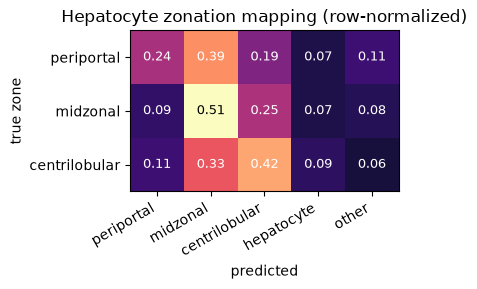

In [4]:
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(tab.values, cmap='magma', vmin=0, vmax=tab.values.max())
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=30, ha='right')
ax.set_yticks(range(3)); ax.set_yticklabels(tab.index)
ax.set_xlabel('predicted'); ax.set_ylabel('true zone')
ax.set_title('Hepatocyte zonation mapping (row-normalized)')
for i in range(tab.shape[0]):
    for j in range(tab.shape[1]):
        v = tab.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v < 0.5 else 'black', fontsize=9)
plt.tight_layout(); plt.show()

## 4. Score it ordinally — zonation is a gradient

Portal→mid→central is ordered, so the honest metrics are **within-1-zone** accuracy and
the rate of **portal↔central** flips (confusing the two extremes).

In [5]:
zi = {ZON[0]: 0, ZON[1]: 1, ZON[2]: 2}
sub['tz'] = sub['cell_type'].map(zi)
sub['pz'] = sub['celltype'].map(zi)          # NaN if predicted a non-zone label
z = sub.dropna(subset=['pz'])
print(f'assigned a zone to {len(z)}/{len(sub)} hepatocytes ({len(z)/len(sub):.0%})')
print(f'exact-zone        : {(z.tz == z.pz).mean():.2f}')
print(f'within-1-zone     : {(abs(z.tz - z.pz) <= 1).mean():.2f}')
print(f'portal<->central  : {((z.tz - z.pz).abs() == 2).mean():.2f}  (extreme mix-ups)')

assigned a zone to 1266/1500 hepatocytes (84%)
exact-zone        : 0.46
within-1-zone     : 0.88
portal<->central  : 0.12  (extreme mix-ups)


**Takeaway.** The zonation axis is recovered — most error is between *adjacent*
zones (within-1-zone ≈ 0.9) and the two extremes are rarely swapped (portal↔central ≈ 0.1)
— but exact-zone boundaries are soft. That's expected: the broad reference carries only
~40 cells per zone. For **crisp** zonation, build a *focused* 3-zone hepatocyte reference
from more cells (`examples/build_reference.py`); the dedicated zonation study in the
[actinn-jax-benchmark](https://github.com/iandriver/actinn-jax-benchmark/blob/main/docs/ZONATION.md)
repo reaches within-1-zone ≈ 0.99, including cross-dataset transfer of the gradient.

## 5. A focused liver reference: `liver_hlica_v1`

The zonation signal above is real but the broad, 798-type reference wasn't built for
this — it has ~15-40 cells per type. `liver_hlica_v1` is a dedicated liver reference
built from [HLiCA](https://doi.org/10.64898/2026.06.30.735539) (Edgar, Portman, Hu et
al. 2026): 522,730 cells, 110 donors, 7 studies, 38 expert-curated types across 6
lineages — thousands of cells per type instead of dozens.

**Note on this demo:** the liver query used above (`liver_zonation_query.h5ad`) turns
out to be drawn from HLiCA's own `Andrews_2022` component study — so it's *inside*
`liver_hlica_v1`'s training data and can't fairly measure its accuracy (the cell below
is a usage illustration only). The rigorous number comes from a proper **cross-study**
held-out test — trained on HLiCA's other 6 studies, evaluated only on the withheld
`Andrews_2022` cells never seen in training — computed separately in
[actinn-jax-benchmark's HLICA_LIVER.md](https://github.com/iandriver/actinn-jax-benchmark/blob/main/docs/HLICA_LIVER.md):

| model | exact-CL | ontology-concordant |
|---|---|---|
| broad_human_v1 (798 types) | 0.231 | 0.580 |
| **liver_hlica_v1** (cross-study held-out) | **0.728** | **0.858** |

| zonation | cells | exact-zone | portal↔central flip |
|---|---|---|---|
| hepatocyte | 27,740 | 0.787 | 0.182 |
| endothelial | 5,382 | 0.711 | 0.264 |

A 3x jump in exact accuracy from retraining on a focused, much larger reference — the
concrete payoff of the `refine_to_query` vs. `build_reference.py` distinction in the
main README: masking the broad reference is safe but doesn't fix accuracy; retraining
does.

In [6]:
liver_model = aj.bundled_reference('liver_hlica_v1')
print(f'{len(liver_model.classes)} types across '
      f'{len(set(liver_model.type_to_group.values()))} lineages')

t = time.perf_counter()
liver_out = aj.annotate(adata.copy(), liver_model)
print(f'annotated {liver_out.n_obs:,} cells in {time.perf_counter()-t:.1f}s '
      '(usage illustration -- see numbers above for the real held-out accuracy)')
liver_out.obs[['celltype', 'celltype_coarse']].head()

38 types across 6 lineages


annotated 5,566 cells in 0.3s (usage illustration -- see numbers above for the real held-out accuracy)


,celltype,celltype_coarse
0,endothelial cell of artery,endothelial
1,Ribosomal+ Hepatocyte,hepatocyte
2,Ribosomal+ Hepatocyte,hepatocyte
3,classical monocyte,myeloid
4,endothelial cell of vascular tree,endothelial


### Attribution

`liver_hlica_v1` is built from data made available by Edgar, R.D., Portman, J.R., Hu,
H. et al. **HLiCA: An integrated cell atlas of the healthy human liver.** bioRxiv
(2026). https://doi.org/10.64898/2026.06.30.735539 (CC-BY 4.0). Please cite the
original paper if you use this reference.